In [2]:
## NO3 Trends - Shapley Values

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import accuracy_score, confusion_matrix
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.datasets import load_iris
#import xgboost as xgb 


In [3]:
import numpy as np

In [4]:
import pandas as pd

import sklearn
import shap

c:\Users\MPennino\miniconda3\envs\rfenvi\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# Load Dataset
# DATA = readRDS(paste0(strap_dir,'Data/Models/RF_bi_model_All_DATA_all_vars_','Trends_Conc_PWS_GW_05to20', '.rds'))
strap_dir = 'C:/Users/MPennino/OneDrive - Environmental Protection Agency (EPA)/Projects/StRAPs/StRAP4/SSWR.405.1_NO3_Trend_Causes/Data/Models/'
FILE_NAME = 'RF_bi_model_All_DATA_all_vars_Trends_Conc_PWS_GW_05to20.csv'
data = pd.read_csv(strap_dir+FILE_NAME)
data.head(3)

,DW_Trend,PctCrop2019Cat,PctForest2019Cat,FertCat,precip9120cat,tmean9120cat,WaterInputCat,BFICat,Precip_Minus_EVTCat,AgKffactCat,...,RockNCat,N_Surp_Change,All_Deficiencies_num,SystemSizePop,Administrative_Penalty_num,AltSource_yn,TreatmentTechniqueViols,MR_num,Nitrate_Treatment_yn,complete_N_mgmt_yn
0,1,0.000000,78.929400,0.000000,518.874944,9.035662,0.000000,32.980380,-4.883228,0.000000,...,25.642382,-163.180641,2,90,0,0,0,167,0,0
1,1,0.000000,78.929400,0.000000,518.874944,9.035662,0.000000,32.980380,-4.883228,0.000000,...,25.642382,-163.180641,0,130,0,0,0,103,0,0
2,-1,2.381455,0.000364,2.640785,161.975930,20.836734,0.094053,16.853464,-91.711311,0.008065,...,317.724395,396.772239,1,3554,0,0,0,115,0,1


In [6]:
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

In [7]:
import matplotlib.pyplot as plt

In [8]:
train,test=train_test_split(data,test_size=0.3,random_state=0,stratify=data['DW_Trend'])


In [9]:
train.head()

,DW_Trend,PctCrop2019Cat,PctForest2019Cat,FertCat,precip9120cat,tmean9120cat,WaterInputCat,BFICat,Precip_Minus_EVTCat,AgKffactCat,...,RockNCat,N_Surp_Change,All_Deficiencies_num,SystemSizePop,Administrative_Penalty_num,AltSource_yn,TreatmentTechniqueViols,MR_num,Nitrate_Treatment_yn,complete_N_mgmt_yn
288,1,2.750952,27.936667,4.419367,1374.024528,21.329746,0.008743,68.645476,27.446876,0.022476,...,89.768943,314.139740,2,1823,1,0,0,26,0,1
674,1,1.061569,8.329804,5.191971,1180.071340,13.388588,0.000017,35.595694,27.602902,0.071763,...,240.287939,-28.173612,3,54,0,0,2,12,0,1
565,1,42.271875,9.970625,35.127279,857.476184,7.185193,0.000219,48.904162,16.968692,0.147396,...,234.968842,1181.146069,0,1868,0,0,0,10,0,0
884,-1,0.300822,62.039452,7.114011,1206.037497,15.349095,0.000059,29.145699,27.266578,0.041803,...,105.707186,-24.019745,0,242,0,0,0,1,0,0
1570,-1,0.000000,80.588511,1.433191,1460.215660,5.629449,0.000035,44.405687,78.719921,0.026904,...,159.990532,-659.090797,7,40,0,0,0,14,0,0


In [10]:
# Convert categorical variables into dummy/indicator variables
train_processed = pd.get_dummies(train)
test_processed = pd.get_dummies(test)
data_processed = pd.get_dummies(data)

# Filling Null Values
train_processed = train_processed.fillna(train_processed.mean())
test_processed = test_processed.fillna(test_processed.mean())

# Create X_train,Y_train,X_test
X_train = train_processed.drop(['DW_Trend'], axis=1)
Y_train = train_processed['DW_Trend']

X_test  = test_processed.drop(['DW_Trend'], axis=1)
Y_test  = test_processed['DW_Trend']

### Model Training

In [11]:
# Random Forest
random_forest = RandomForestClassifier(n_estimators=100)
random_forest.fit(X_train, Y_train)
random_forest_preds = random_forest.predict(X_test)
print('The accuracy of the Random Forests model is :\t',metrics.accuracy_score(random_forest_preds,Y_test))

The accuracy of the Random Forests model is :	 0.7608247422680412


In [12]:
# Create Tree Explainer object that can calculate shap values
explainer = shap.TreeExplainer(random_forest)

In [13]:
#Let's choose some instances from the test dataset to understand to the classifier makes predictions for them.
test.loc[[50]]

,DW_Trend,PctCrop2019Cat,PctForest2019Cat,FertCat,precip9120cat,tmean9120cat,WaterInputCat,BFICat,Precip_Minus_EVTCat,AgKffactCat,...,RockNCat,N_Surp_Change,All_Deficiencies_num,SystemSizePop,Administrative_Penalty_num,AltSource_yn,TreatmentTechniqueViols,MR_num,Nitrate_Treatment_yn,complete_N_mgmt_yn
50,-1,20.714324,15.570541,85.262797,948.685849,14.556658,0.007014,35.489232,18.662268,0.085251,...,116.912878,-1072.865861,0,188,0,0,0,20,0,1


In [14]:
# Calculate Shap values for test dataset
#choosen_instance = X_test.loc[[50]]
#shap_values = explainer.shap_values(choosen_instance)
shap_values1 = explainer(X_test) # 5 sec

#shap.initjs()
#shap.force_plot(explainer.expected_value[1], shap_values[1], choosen_instance)

In [15]:
data_processed.shape

(1614, 29)

In [16]:
# Calculate Shap values for all sites
#choosen_instance = X_test.loc[[50]]
#shap_values = explainer.shap_values(choosen_instance)
shap_values = explainer(data_processed) # 14 sec

In [17]:
shap_values.shape[0]

1614

In [18]:
reshaped_data = shap_values[:,:,0]
# reshaped_data = shap_values.values.reshape(shap_values.shape[0], -1) # Results in shape (1614, 58)
#df = pd.DataFrame(reshaped_data)

In [19]:
reshaped_data.shape

(1614, 29)

In [20]:
shap_df = pd.DataFrame(
    reshaped_data.values, 
    columns=reshaped_data.feature_names
)

In [21]:
shap_df.head()

,DW_Trend,PctCrop2019Cat,PctForest2019Cat,FertCat,precip9120cat,tmean9120cat,WaterInputCat,BFICat,Precip_Minus_EVTCat,AgKffactCat,...,RockNCat,N_Surp_Change,All_Deficiencies_num,SystemSizePop,Administrative_Penalty_num,AltSource_yn,TreatmentTechniqueViols,MR_num,Nitrate_Treatment_yn,complete_N_mgmt_yn
0,0.000598,-0.002183,0.008064,-0.001640,0.024564,0.023834,0.015639,0.001468,0.019777,-0.003850,...,-0.005658,0.007112,-0.000093,0.028853,-0.001137,0.000700,0.010497,0.003205,-0.000553,0.0
1,0.000585,-0.002057,0.008074,-0.001501,0.024050,0.026407,0.015617,0.001003,0.019746,-0.003542,...,-0.005672,0.007105,-0.000093,0.026336,-0.001140,0.000702,0.010300,0.003197,-0.000553,0.0
2,-0.020724,-0.000576,0.008771,-0.007692,0.012505,0.023404,0.014517,0.004680,0.022683,-0.005257,...,-0.001572,-0.024757,0.001826,0.019184,-0.000879,0.000170,0.011989,0.002903,-0.000376,0.0
3,-0.021105,-0.000947,0.010000,-0.007513,0.013543,0.025731,0.013238,0.004014,0.022891,-0.005201,...,-0.001559,-0.025221,0.002397,0.022697,-0.000945,0.000150,0.009526,0.002716,-0.000391,0.0
4,-0.020691,-0.000480,0.008860,-0.007263,0.013074,0.022836,0.013704,0.004671,0.021870,-0.005035,...,-0.001666,-0.024637,0.001715,0.018838,-0.000879,0.001550,0.011884,0.002929,-0.000375,0.0


In [28]:
# Save SHAP results

shap_dir = 'C:/Users/MPennino/OneDrive - Environmental Protection Agency (EPA)/Projects/StRAPs/StRAP4/SSWR.405.1_NO3_Trend_Causes/Data/SHAP/'
FILE_NAME = 'SHAP_Results_RF_Conc_PWS_GW_05to20.csv'
shap_df.to_csv(shap_dir+FILE_NAME, index=False) # Set index=False to avoid writing the DataFrame index as a column

In [22]:
X_test.shape, X_train.shape

((485, 28), (1129, 28))

In [ ]:
#test test

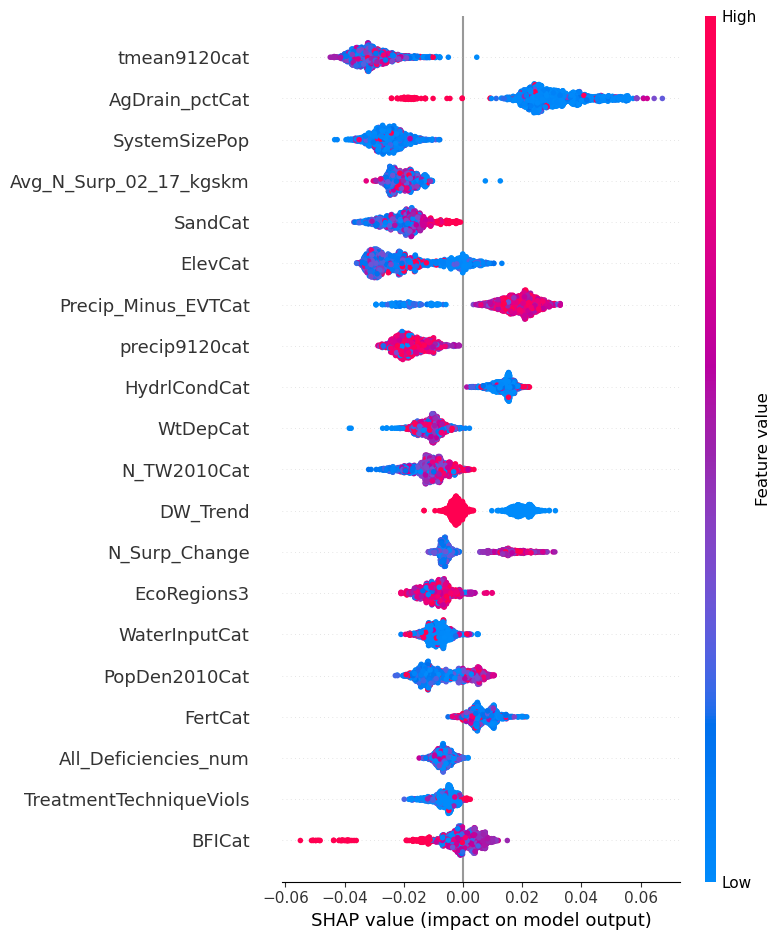

In [23]:
#shap.summary_plot(shap_values[:,:,1], X_test)
shap.summary_plot(shap_values[:,:,1], data)

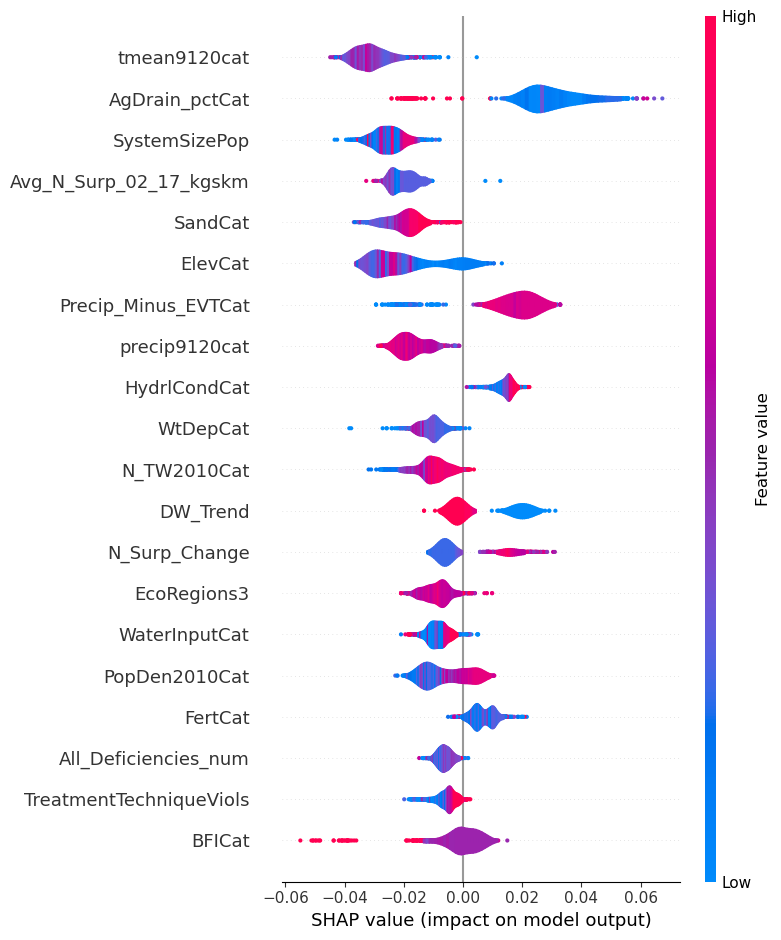

In [24]:
shap.summary_plot(shap_values[:,:,1], plot_type='violin')


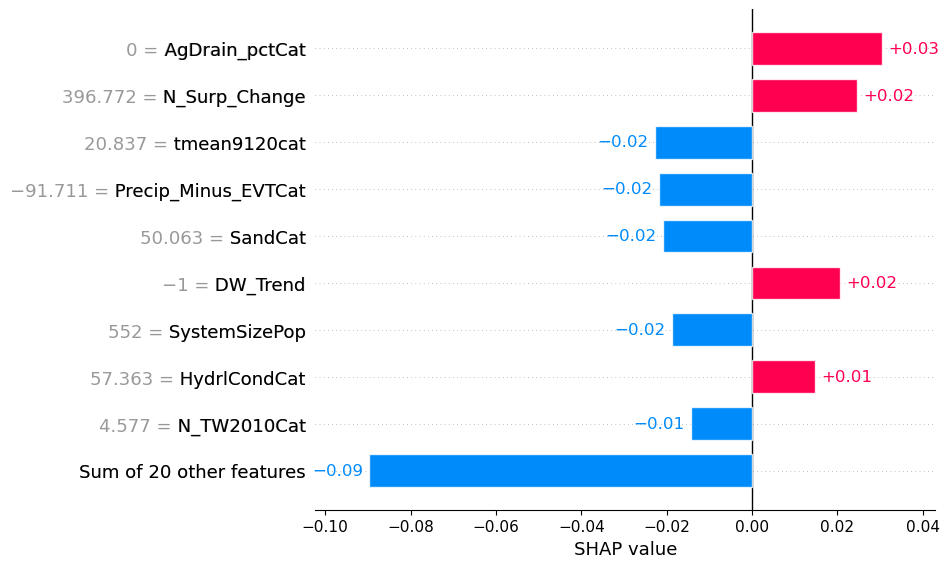

In [25]:
# Local Bar plot
shap.plots.bar(shap_values[:,:,1][4])

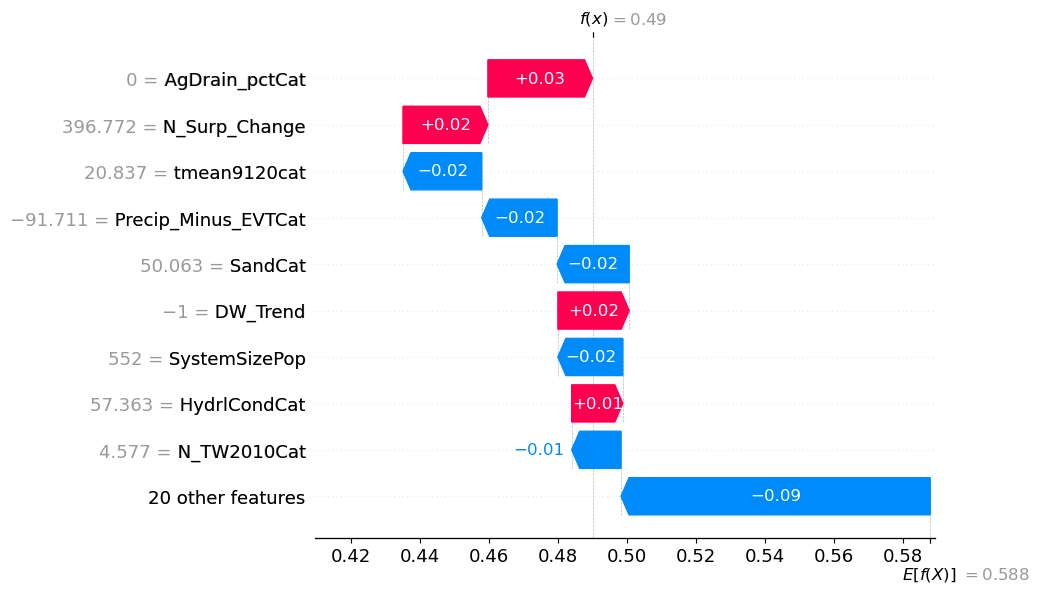

In [26]:
# Local Waterfall plot
shap.plots.waterfall(shap_values[:,:,1][4])

# "Hello World!"

In [27]:
# Updates